In [60]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [61]:
#df['day'].nunique()
df.time.unique()

['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']

In [62]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['time']=le.fit_transform(df.time)
df.time.value_counts()

time
0    176
1     68
Name: count, dtype: int64

In [63]:
x=df.drop(labels=['time'],axis=1)
y=df.time

In [64]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape

((195, 6), (49, 6))

In [169]:
import seaborn as sns
import pandas as pd
df=sns.load_dataset('tips')
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['time']=le.fit_transform(df.time)
x=df.drop(labels=['time'],axis=1)
y=df.time
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer #handle missing values
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
cat_cols=['sex','smoker','day']
num_cols=['total_bill','tip','size']
##Numerical columns pipeline
num_pipeline=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')), #missing values handled
        ('scaler',StandardScaler()) #feature scaling
    ]
)
cat_pipeline=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehotencoder',OneHotEncoder(drop='first')) #catagorical features to numerical encoding
    ]
)
preprocessor=ColumnTransformer([
    ('num_pipeline',num_pipeline,num_cols),
    ('cat_pipeline',cat_pipeline,cat_cols)
])
x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
models={
    'Random Forest':RandomForestClassifier(n_estimators=10,max_depth=4),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=3)
}
from sklearn.metrics import accuracy_score
#accuracy_score(y_test, y_pred)


In [170]:
def eval_model(x_train,y_train,x_test,y_test,models):
    report={}
    for i in range(len(models)):
        model=list(models.values())[i] #pick specific model
        model.fit(x_train,y_train) #train data on that specific model
        y_test_pred=model.predict(x_test)
        test_model_score=accuracy_score(y_test,y_test_pred)
        report[list(models.keys())[i]]=test_model_score
    return report

In [171]:
rep=eval_model(x_train,y_train,x_test,y_test,models)
rep

{'Random Forest': 1.0,
 'Logistic Regression': 1.0,
 'Decision Tree': 0.9591836734693877}

In [131]:
import pandas as pd

# Create a MultiIndex
index = pd.MultiIndex.from_tuples([('A', 2020), ('A', 2021), ('B', 2020),
                                   ('B', 2021), ('C', 2020), ('C', 2021)],
                                  names=['Company', 'Year'])

# Create the DataFrame
data = {
    'Revenue': [100, 150, 200, 250, 300, 350],
    'Profit': [10, 15, 20, 25, 30, 35]
}

df = pd.DataFrame(data, index=index)
print(df)

              Revenue  Profit
Company Year                 
A       2020      100      10
        2021      150      15
B       2020      200      20
        2021      250      25
C       2020      300      30
        2021      350      35


In [132]:
print(df.loc['A'])

      Revenue  Profit
Year                 
2020      100      10
2021      150      15


In [7]:
print(df.loc[("A",2021)])

Revenue    150
Profit      15
Name: (A, 2021), dtype: int64


In [1]:
import numpy as np
import pandas as pd
data = {'Country': ['Belgium',  'India',  'Brazil'],
'Capital': ['Brussels',  'New Delhi',  'Brasilia'],
'Population': [11190846, 1303171035, 207847528]}
df = pd.DataFrame(data) #,columns=['Country',  'Capital',  'Population'])
print(df.to_string())
#df.loc[0,0]

   Country    Capital  Population
0  Belgium   Brussels    11190846
1    India  New Delhi  1303171035
2   Brazil   Brasilia   207847528


In [32]:
a=pd.DataFrame(np.random.randint(30,99,(5,4)),columns=list("abcd"))
print(a['a'])
a['a'][2:].values.tolist()

0    44
1    90
2    33
3    69
4    54
Name: a, dtype: int32


[33, 69, 54]

In [67]:
import pandas as pd
#df=pd.read_table('tg.txt',sep=',')
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/ToothGrowth.csv")
df.head(2)

,len,supp,dose
0,4.2,VC,0.5
1,11.5,VC,0.5


In [56]:
data = np.arange(10)
index = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

ser = pd.Series(data=data, index=index, name='numbers')  # name is optional. 
ser.keys()

# IF you don't provide index, pandas will create a default starting with 0 

Index(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'], dtype='object')

In [3]:
import pandas as pd
#from pandas_summary import DataFrameSummary
df = pd.read_csv("C:\\learn_python\\selva_prabhakaran\\pandas\\churn.txt")
df
#print(type(df.columns))
#df.rename(columns={'account_length': 'account length'},inplace=True)
#df['state'].value_counts(normalize=True).sum()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [47]:
ser = pd.Series(np.random.randint(1,100, 10),index=list('abcdefghij'))
print(ser)
b=pd.Series((ser.values[1:] - ser.values[:-1]),index=ser.keys()[1:10])
b['a']=ser['a']
a=ser.diff()
print(b.sort_index())

a    27
b     5
c    97
d    33
e    73
f    13
g    44
h     4
i    94
j    12
dtype: int32
a    27
b   -22
c    92
d   -64
e    40
f   -60
g    31
h   -40
i    90
j   -82
dtype: int32


In [18]:
import numpy as np
import pandas as pd
from pandas_summary import DataFrameSummary
data = {'Country': ['Belgium',  'India',  'Brazil'],
'Capital': ['Brussels',  'New Delhi',  'Brasilia'],
'Population': [11190846, 1303171035, 207847528]}
df = pd.DataFrame(data)
print(df.loc[df['Country']=='India','Country':'Capital'])
print(df.iloc[df[(df['Country']=='Belgium')|(df['Country']=='Brazil')].index])
#dfs = DataFrameSummary(df)
#dfs.columns_stats

  Country    Capital
1   India  New Delhi
   Country   Capital  Population
0  Belgium  Brussels    11190846
2   Brazil  Brasilia   207847528


In [3]:
import logging
logging.warning('Watch out!') # will print a message to the console
logging.info('I told you so')

In [3]:
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(filename='example.log', encoding='utf-8', level=logging.DEBUG)
logger.debug('This message should go to the log file')
logger.info('So should this')
logger.warning('And this, too')
logger.error('And non-ASCII stuff, too, like Øresund and Malmö')

ERROR:__main__:And non-ASCII stuff, too, like Øresund and Malmö


In [6]:
%reload_ext cython

In [7]:
%%cython

UsageError: %%cython is a cell magic, but the cell body is empty.


In [1]:
import sys
#import Cython
import numpy as np
import subprocess, os
print("Python %d.%d.%d %s %s" % sys.version_info)
#print("Cython %s" % Cython.__version__)
print("Numpy %s" % np.__version__)
#print(subprocess.check_output([os.environ.get('CC','cc'),"--version"]).decode().splitlines()[0])
#print([line for line in subprocess.check_output([os.environ.get('CC','cc'),"--version","-v"],stderr=subprocess.STDOUT).decode().splitlines() if ' version ' in line][0])

Python 3.12.3 final 0
Numpy 1.26.4


In [1]:
from typing import Dict, Tuple
from datetime import datetime
from pyspark.sql.functions import col, when, monotonically_increasing_id, lit, max as spark_max
from pyspark.sql import SparkSession, Column, Row
s = SparkSession.builder \
        .appName("RetailDataAnalysis") \
        .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.2") \
        .config("spark.hadoop.io.native.lib", "None") \
        .config("spark.hadoop.io.native.lib", "false").getOrCreate()
curr_date = datetime.now().strftime("%Y%m%d")
curr_time = datetime.now().strftime("%H:%M:%S")
dimension_to_key_field_map: Dict[str, Tuple[str, str]] = {"CustomerCountry": ("Customer_ID", "Country"),
                                                              "Stock": ("StockCode", "Description")}
control_data = [Row(Dimension=dimension_name, LastProcessedKey=-1)#, RunTime=f'{curr_date}_{curr_time}')
                        for dimension_name in dimension_to_key_field_map]
control_table = s.createDataFrame(control_data)
control_table.show(4, truncate=0)
last_processed_key = control_table.filter(col("Dimension") == "CustomerCountry").select("LastProcessedKey").collect()[0][0]
print(last_processed_key)

+---------------+----------------+
|Dimension      |LastProcessedKey|
+---------------+----------------+
|CustomerCountry|-1              |
|Stock          |-1              |
+---------------+----------------+

-1


In [3]:
import os
from typing import Dict, Tuple, Union
from datetime import datetime
from pyspark.sql.functions import col, when, monotonically_increasing_id, lit, max as spark_max
from pyspark.sql import SparkSession, Column, Row
from pyspark.sql.dataframe import DataFrame
# Set Python executable path
python_executable = "C:\\Users\\badri\\AppData\\Local\\Programs\\Python\\Python312\\python.exe"  # Make sure this is the correct path to your Python 3.12 executable
#python_executable="C:\\anaconda3\\python.exe"
# Set environment variables for PySpark
os.environ["PYSPARK_PYTHON"] = python_executable
os.environ["PYSPARK_DRIVER_PYTHON"] = python_executable
print("PYSPARK_PYTHON:", os.environ["PYSPARK_PYTHON"])
print("PYSPARK_DRIVER_PYTHON:", os.environ["PYSPARK_DRIVER_PYTHON"])
s = SparkSession.builder \
    .appName("RetailDataAnalysis") \
    .config("spark.pyspark.python", python_executable) \
    .config("spark.pyspark.driver.python", python_executable) \
    .getOrCreate()
df = s.createDataFrame(
    [("560241", "15056", "EDWARDIAN PARASOL NATURAL", "6", "7/17/11 12:02",
      "5.95", "13967", "United Kingdom"),
     ("560242", "22326", "ROUND SNACK BOXES SET OF4 WOODLAND", "10",
      "7/17/11 12:03", "9.95", "14659", "United Kingdom"),
     ("560243", "22501", "PICNIC BASKET 2X LARGE", "1", "7/17/11 12:04",
      "9.95", "14659", "United Kingdom"),
     ("561341", "22501", "PICNIC BASKET 2X LARGE", "5", "8/12/11 2:07",
      "39.95", "14659", "India"),
     ("580972", "21328", "BALLOONS WRITING SET", "15", "12/17/11 7:36",
      "27.45", "14659", "India"),
     ("636370", "22326", "ROUND SNACK BOXES SET OF4 WOODLAND", "24",
      "6/6/12 8:45", "24.95", "12583", "France"),
     ("656861", "21328", "BALLOONS WRITING SET", "12", "12/1/12 10:44", "1.65",
      "12427", "Germany"),
     ("727236", "21328", "BALLOONS WRITING SET", "25", "12/27/12 9:27",
      "36.63", "12427", "Portugal")], [
          "Invoice", "StockCode", "Description", "Quantity", "InvoiceDate",
          "Price", "Customer ID", "Country"
      ])
#s.createDataFrame(df.tail(5)).show(truncate=0)
#df.show(truncate=0)
# for i in l1:
#     print(i)

PYSPARK_PYTHON: C:\Users\badri\AppData\Local\Microsoft\WindowsApps\python.exe
PYSPARK_DRIVER_PYTHON: C:\Users\badri\AppData\Local\Microsoft\WindowsApps\python.exe


In [29]:
spark.stop()

ec.count()=5
+-----------+-------------+--------------+------+--------------------+------------------+
|Customer_ID|Invoice_Date |Country_ec    |Active|effective_start_date|effective_end_date|
+-----------+-------------+--------------+------+--------------------+------------------+
|12427      |12/1/12 10:44|Germany       |y     |12/1/12 10:44       |9999-12-31        |
|13509      |7/17/11 12:02|United Kingdom|y     |7/17/11 12:02       |9999-12-31        |
|13967      |3/30/11 13:01|United Kingdom|y     |3/30/11 13:01       |9999-12-31        |
|13967      |9/8/11 5:04  |Australia     |y     |9/8/11 5:04         |9999-12-31        |
|14659      |7/17/11 12:03|United Kingdom|y     |7/17/11 12:03       |9999-12-31        |
+-----------+-------------+--------------+------+--------------------+------------------+

s.count()=7
+-------+---------+----------------------------------+--------+-------------+-----+-----------+--------------+
|Invoice|StockCode|Description                       

In [59]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, when, min
from pyspark.sql.window import Window

# Initialize Spark session
spark = SparkSession.builder.appName("SCD_Type_2_Merge").getOrCreate()

# Load Customer DataFrame
customer_df1 = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\CustomerCountry.csv", header=True, inferSchema=True)

# Set effective start and end dates for customer records, and ensure 'Active' column is maintained
customer_df = customer_df1.withColumn('effective_start_date', col("InvoiceDate")) \
                          .withColumn("effective_end_date", lit("9999-12-31")) \
                          .select("Customer_ID", "InvoiceDate", "Country", "Active", "effective_start_date", "effective_end_date")

# Load Retail DataFrame
retail_data_df1 = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\online_retail_II_v2.csv", header=True, inferSchema=True)

# Remove spaces from retail columns for easier referencing
retail_data_df = retail_data_df1.toDF(*[c.replace(' ', '_') for c in retail_data_df1.columns])

# Staging DataFrame: Join retail data to customer dimension based on Customer_ID
staging_df = retail_data_df.alias("r").join(customer_df.alias("c"), ["Customer_ID"], "left_outer") \
                              .select(
                                  col("r.Customer_ID").alias("RetailCustomerID"),
                                  col("r.InvoiceDate").alias("RetailInvoiceDate"),
                                  col("r.Country").alias("RetailCountry"),
                                  when(col("c.Customer_ID").isNull(), lit("y")).otherwise(lit("n")).alias("RetailActive"),
                                  col("r.InvoiceDate").alias("retail_effective_start_date"),
                                  # Check if customer exists, otherwise set default effective end date
                                  when(col("c.Customer_ID").isNull(), lit("9999-12-31"))
                                  .otherwise(min(col("c.effective_start_date")).over(Window.partitionBy("c.Customer_ID").orderBy("r.InvoiceDate")))
                                  .alias("retail_effective_end_date")
                              )

# Update existing records by closing current active records
updated_customer_df = staging_df.alias("s").join(
    customer_df.alias("c"),
    (col("s.RetailCustomerID") == col("c.Customer_ID")) &
    (col("s.retail_effective_start_date") >= col("c.effective_start_date")) &
    (col("c.effective_end_date") == lit("9999-12-31")),
    "left"
).select(
    col("s.RetailCustomerID").alias("Customer_ID"),
    col("s.RetailInvoiceDate").alias("InvoiceDate"),
    col("s.RetailCountry").alias("Country"),
    lit("n").alias("Active"),  # Mark the record as inactive
    col("c.effective_start_date"),
    col("s.retail_effective_start_date").alias("effective_end_date")  # Set the end date when the new record starts
)

# Create new records for changes or new customers
new_records_df = staging_df.alias("s").join(
    customer_df.alias("c"),
    (col("s.RetailCustomerID") == col("c.Customer_ID")),
    "left"
).filter(
    (col("c.Customer_ID").isNull()) |  # For new customers
    (col("s.RetailCountry") != col("c.Country"))  # Or if the country has changed
).select(
    col("s.RetailCustomerID").alias("Customer_ID"),
    col("s.RetailInvoiceDate").alias("InvoiceDate"),
    col("s.RetailCountry").alias("Country"),
    lit("y").alias("Active"),  # New record marked as active
    col("s.retail_effective_start_date").alias("effective_start_date"),
    lit("9999-12-31").alias("effective_end_date")  # Default future date for active records
)

# Combine updated and new records to get the final customer dimension
final_customer_df = updated_customer_df.union(new_records_df)

# Show the final result of merged customer dimension
final_customer_df.show(truncate=0)
new_records_df.show(truncate=0)
updated_customer_df.show(truncate=0)
staging_df.show(truncate=0)
customer_df.show(truncate=0)
retail_data_df.show(truncate=0)

+-----------+-------------+--------------+------+--------------------+------------------+
|Customer_ID|InvoiceDate  |Country       |Active|effective_start_date|effective_end_date|
+-----------+-------------+--------------+------+--------------------+------------------+
|13509      |9/28/11 7:02 |Italy         |n     |7/17/11 12:02       |9/28/11 7:02      |
|14659      |7/17/11 12:03|United Kingdom|n     |7/17/11 12:03       |7/17/11 12:03     |
|14659      |8/12/11 2:07 |India         |n     |7/17/11 12:03       |8/12/11 2:07      |
|14659      |12/17/11 7:36|Japan         |n     |NULL                |12/17/11 7:36     |
|12583      |6/6/12 8:45  |France        |n     |NULL                |6/6/12 8:45       |
|12427      |12/1/12 10:44|Germany       |n     |12/1/12 10:44       |12/1/12 10:44     |
|12427      |12/27/12 9:27|Portugal      |n     |12/1/12 10:44       |12/27/12 9:27     |
|13509      |9/28/11 7:02 |Italy         |y     |9/28/11 7:02        |9999-12-31        |
|14659    

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, row_number, when, to_timestamp, date_format, coalesce
from pyspark.sql.window import Window
from typing import Tuple
from pyspark.sql.dataframe import DataFrame

def scd_type2_merge_customercountry(o4_df: DataFrame, cc_df: DataFrame) -> DataFrame:
    join_condition = o4_df["CUSTOMERID"] == cc_df["CUSTOMER_ID"]
    o_df = o4_df.alias("o4").join(cc_df.alias("cc"), join_condition, "full_outer")
    only_old_df = o_df.filter(col("o4.CUSTOMERID").isNull()).select(
        lit('ONLY OLD').alias('tag'),
        col("cc.CUSTOMER_ID"),
        col("cc.INVOICE_DATE"),
        col("cc.COUNTRY"),
        col("cc.ACTIVE"),
        col("cc.EFFECTIVE_START_DATE"),
        col("cc.EFFECTIVE_END_DATE")
    )
    only_new_df = o_df.filter(col("CUSTOMER_ID").isNull()).select(
        lit('ONLY NEW').alias('tag'),
        col("o4.CUSTOMERID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY"),
        lit('y').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    old_df = cc_df.select(
        lit('OLD').alias('tag'),
        col("CUSTOMER_ID"),
        col("INVOICE_DATE"),
        col("COUNTRY"),
        col("ACTIVE"),
        col("EFFECTIVE_START_DATE"),
        col("EFFECTIVE_END_DATE")
    )
    changed_df = o_df.filter((col("o4.CUSTOMERID") == col("cc.CUSTOMER_ID")) & (col("o4.COUNTRY") != col("cc.COUNTRY")) & (col("cc.ACTIVE") == 'y')).select(
        lit('CHANGED').alias('tag'),
        col("o4.CUSTOMERID").alias("CUSTOMER_ID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY").alias("COUNTRY"),
        lit('y').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    common_df = o_df.filter((col("o4.CUSTOMERID") == col("cc.CUSTOMER_ID")) & (col("o4.COUNTRY") == col("cc.COUNTRY")) & (col("cc.ACTIVE") == 'y')).select(
        lit('COMMON').alias('tag'),
        col("o4.CUSTOMERID").alias("CUSTOMER_ID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY"),
        lit('n').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    p_df = only_old_df.union(only_new_df).union(old_df).union(changed_df).union(common_df)
    p_df = p_df.withColumn("INVOICE_DATE", to_timestamp(col("INVOICE_DATE"), "MM/dd/yy HH:mm"))
    window_spec_1 = Window.partitionBy("CUSTOMER_ID", "COUNTRY").orderBy(col("INVOICE_DATE").desc())
    p_df = p_df.withColumn("rn", row_number().over(window_spec_1))
    filtered_p_df = p_df.filter(col("rn") == 1)
    window_spec_2 = Window.partitionBy("CUSTOMER_ID", "ACTIVE").orderBy(col("INVOICE_DATE").desc())
    merged_customercountry_df = filtered_p_df.withColumn("rn1", row_number().over(window_spec_2))
    merged_customercountry_df = merged_customercountry_df.withColumn("ACTIVE", when(col("rn1") == 1, lit("y")).otherwise(lit("n"))) \
                       .withColumn("EFFECTIVE_END_DATE", when(col("rn1") == 1, col("EFFECTIVE_END_DATE")).otherwise(col("INVOICE_DATE")))
    merged_customercountry_df = merged_customercountry_df.select(
        "CUSTOMER_ID",
        "INVOICE_DATE",
        "COUNTRY",
        "ACTIVE",
        "EFFECTIVE_START_DATE",
        "EFFECTIVE_END_DATE"
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "INVOICE_DATE", to_timestamp(col("INVOICE_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", to_timestamp(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "EFFECTIVE_END_DATE",
        when(col("EFFECTIVE_END_DATE") == '12/31/99 23:59', 
             to_timestamp(lit('12/31/99 23:59'), 'MM/dd/yy HH:mm'))  # Handle the special case
        .otherwise(
            coalesce(
                to_timestamp(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm"),  # Try the default format
                to_timestamp(col("EFFECTIVE_END_DATE"), "yyyy-MM-dd HH:mm:ss"),  # Try another possible format
                lit('12/31/99 23:59')  # Fallback to default if still unparseable
            )
        )
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "INVOICE_DATE", date_format(col("INVOICE_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", date_format(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_END_DATE", date_format(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm")
    )
    return merged_customercountry_df


spark = SparkSession.builder.appName("SCD_Type_2_Merge").getOrCreate()

o4_df = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\online_retail_II_v2.csv", header=True, inferSchema=True)
o4_df = o4_df.toDF(*[c.replace(' ', '') for c in o4_df.columns])
cc_df = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\CustomerCountry.csv", header=True, inferSchema=True)
cc_df = cc_df.withColumn('effective_start_date', col("InvoiceDate")).withColumn("effective_end_date", lit('12/31/99 23:59'))\
.select(col("Customer_ID").alias("CUSTOMER_ID"),col("InvoiceDate").alias("INVOICE_DATE"),col("Country"),"Active","effective_start_date","effective_end_date")
merged_cc=scd_type2_merge_customercountry(o4_df,cc_df)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
merged_cc.show(truncate=0)

+-----------+--------------+--------------+------+--------------------+------------------+
|CUSTOMER_ID|INVOICE_DATE  |COUNTRY       |ACTIVE|EFFECTIVE_START_DATE|EFFECTIVE_END_DATE|
+-----------+--------------+--------------+------+--------------------+------------------+
|12427      |12/27/12 09:27|Portugal      |y     |12/27/12 09:27      |12/31/99 23:59    |
|12427      |09/16/12 10:44|Germany       |n     |09/16/12 10:44      |09/16/12 10:44    |
|12583      |06/06/12 08:45|France        |y     |06/06/12 08:45      |12/31/99 23:59    |
|13509      |09/28/11 07:02|Italy         |y     |09/28/11 07:02      |12/31/99 23:59    |
|13509      |07/17/11 12:02|United Kingdom|n     |07/17/11 12:02      |07/17/11 12:02    |
|13967      |08/09/11 05:04|Australia     |y     |08/09/11 05:04      |12/31/99 23:59    |
|13967      |03/30/11 13:01|United Kingdom|n     |03/30/11 13:01      |03/30/11 13:01    |
|14659      |07/17/11 12:03|United Kingdom|y     |07/17/11 12:03      |12/31/99 23:59    |

In [2]:
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql.functions import col, lit, row_number, when, to_timestamp, date_format, coalesce
from pyspark.sql.window import Window


def scd_type2_merge_customercountry(o4_df: DataFrame, cc_df: DataFrame) -> DataFrame:
    join_condition = o4_df["CUSTOMERID"] == cc_df["CUSTOMER_ID"]
    o_df = o4_df.alias("o4").join(cc_df.alias("cc"), join_condition, "full_outer")
    only_old_df = o_df.filter(col("o4.CUSTOMERID").isNull()).select(
        lit('ONLY OLD').alias('tag'),
        col("cc.CUSTOMER_ID"),
        col("cc.INVOICE_DATE"),
        col("cc.COUNTRY"),
        col("cc.ACTIVE"),
        col("cc.EFFECTIVE_START_DATE"),
        col("cc.EFFECTIVE_END_DATE")
    )
    only_new_df = o_df.filter(col("CUSTOMER_ID").isNull()).select(
        lit('ONLY NEW').alias('tag'),
        col("o4.CUSTOMERID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY"),
        lit('y').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    old_df = cc_df.select(
        lit('OLD').alias('tag'),
        col("CUSTOMER_ID"),
        col("INVOICE_DATE"),
        col("COUNTRY"),
        col("ACTIVE"),
        col("EFFECTIVE_START_DATE"),
        col("EFFECTIVE_END_DATE")
    )
    changed_df = o_df.filter(
        (col("o4.CUSTOMERID") == col("cc.CUSTOMER_ID")) & (col("o4.COUNTRY") != col("cc.COUNTRY")) & (
                col("cc.ACTIVE") == 'y')).select(
        lit('CHANGED').alias('tag'),
        col("o4.CUSTOMERID").alias("CUSTOMER_ID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY").alias("COUNTRY"),
        lit('y').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    common_df = o_df.filter(
        (col("o4.CUSTOMERID") == col("cc.CUSTOMER_ID")) & (col("o4.COUNTRY") == col("cc.COUNTRY")) & (
                col("cc.ACTIVE") == 'y')).select(
        lit('COMMON').alias('tag'),
        col("o4.CUSTOMERID").alias("CUSTOMER_ID"),
        col("o4.INVOICEDATE").alias("INVOICE_DATE"),
        col("o4.COUNTRY"),
        lit('n').alias("ACTIVE"),
        col("o4.INVOICEDATE").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    p_df = only_old_df.union(only_new_df).union(old_df).union(changed_df).union(common_df)
    p_df = p_df.withColumn("INVOICE_DATE", to_timestamp(col("INVOICE_DATE"), "MM/dd/yy HH:mm"))
    window_spec_1 = Window.partitionBy("CUSTOMER_ID", "COUNTRY").orderBy(col("INVOICE_DATE").desc())
    p_df = p_df.withColumn("rn", row_number().over(window_spec_1))
    filtered_p_df = p_df.filter(col("rn") == 1)
    window_spec_2 = Window.partitionBy("CUSTOMER_ID", "ACTIVE").orderBy(col("INVOICE_DATE").desc())
    merged_customercountry_df = filtered_p_df.withColumn("rn1", row_number().over(window_spec_2))
    merged_customercountry_df = merged_customercountry_df.withColumn("ACTIVE",
                                                                     when(col("rn1") == 1, lit("y")).otherwise(
                                                                         lit("n"))) \
        .withColumn("EFFECTIVE_END_DATE",
                    when(col("rn1") == 1, col("EFFECTIVE_END_DATE")).otherwise(col("INVOICE_DATE")))
    merged_customercountry_df = merged_customercountry_df.select(
        "CUSTOMER_ID",
        "INVOICE_DATE",
        "COUNTRY",
        "ACTIVE",
        "EFFECTIVE_START_DATE",
        "EFFECTIVE_END_DATE"
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "INVOICE_DATE", to_timestamp(col("INVOICE_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", to_timestamp(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "EFFECTIVE_END_DATE",
        when(col("EFFECTIVE_END_DATE") == '12/31/99 23:59',
             to_timestamp(lit('12/31/99 23:59'), 'MM/dd/yy HH:mm'))  # Handle the special case
        .otherwise(
            coalesce(
                to_timestamp(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm"),  # Try the default format
                to_timestamp(col("EFFECTIVE_END_DATE"), "yyyy-MM-dd HH:mm:ss"),  # Try another possible format
                lit('12/31/99 23:59')  # Fallback to default if still unparseable
            )
        )
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "INVOICE_DATE", date_format(col("INVOICE_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", date_format(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_END_DATE", date_format(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm")
    )
    return merged_customercountry_df


def scd_type2_merge_stock(invoice_df, stock_df) -> DataFrame:
    joined_df = stock_df.alias("s").join(
        invoice_df.alias("o"), stock_df["StockCode"] == invoice_df["StockCode"], "full_outer"
    ).select(
        stock_df["StockCode"].alias("sstockcode"),
        stock_df["InvoiceDate"].alias("sinvoicedate"),
        stock_df["Description"].alias("sdescription"),
        invoice_df["Invoice"].alias("InvoiceNo"),
        invoice_df["StockCode"],
        invoice_df["Description"],
        invoice_df["Quantity"],
        invoice_df["InvoiceDate"],
        invoice_df["Price"],
        invoice_df["CustomerID"],
        invoice_df["Country"],
        stock_df["Active"],
        stock_df["Effective_Start_Date"],
        stock_df["Effective_End_Date"]
    )
    condition = when(col("stockcode").isNull(), "ONLY OLD"). \
        when(col("sstockcode").isNull(), "ONLY NEW"). \
        when((col("sstockcode") == col("stockcode")) & (col("sdescription") != col("description")), "CHANGED"). \
        when((col("sstockcode") == col("stockcode")) & (col("sdescription") == col("description")), "COMMON")
    joined_df = joined_df.withColumn("tag", condition)
    only_old_df = joined_df.filter(col("tag") == "ONLY OLD").select(
        lit("ONLY OLD").alias("tag"),
        col("sstockcode").alias("StockCode"),
        col("sinvoicedate").alias("InvoiceDate"),
        col("sdescription").alias("Description"),
        col("Active"),
        col("Effective_Start_Date"),
        col("Effective_End_Date")
    )
    only_new_df = joined_df.filter(col("tag") == "ONLY NEW").select(
        lit("ONLY NEW").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("y").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        lit("12/31/99 23:59").alias("Effective_End_Date")
    )
    old_df = stock_df.select(
        lit('OLD').alias('tag'),
        col("StockCode"),
        col("InvoiceDate"),
        col("Description"),
        col("ACTIVE"),
        col("EFFECTIVE_START_DATE"),
        col("EFFECTIVE_END_DATE")
    )
    changed_df = joined_df.filter(col("tag") == "CHANGED").select(
        lit("CHANGED").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("y").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        lit("12/31/99 23:59").alias("Effective_End_Date")
    )
    common_df = joined_df.filter(col("tag") == "COMMON").select(
        lit("COMMON").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("n").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        col("Effective_End_Date")
    )
    p_df = only_old_df.union(only_new_df).union(old_df).union(changed_df).union(common_df)
    p_df = p_df.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm"))
    window_spec_1 = Window.partitionBy("StockCode", "Description").orderBy(col("InvoiceDate").desc())
    p_df = p_df.withColumn("rn", row_number().over(window_spec_1))
    filtered_p_df = p_df.filter(col("rn") == 1)
    window_spec_2 = Window.partitionBy("StockCode", "ACTIVE").orderBy(col("InvoiceDate").desc())
    merged_stock_df = filtered_p_df.withColumn("rn1", row_number().over(window_spec_2))
    merged_stock_df = merged_stock_df.withColumn("ACTIVE", when(col("rn1") == 1, lit("y")).otherwise(lit("n"))) \
        .withColumn("EFFECTIVE_END_DATE",
                    when(col("rn1") == 1, col("EFFECTIVE_END_DATE")).otherwise(col("InvoiceDate")))
    merged_stock_df = merged_stock_df.select(
        "StockCode",
        "InvoiceDate",
        "Description",
        "ACTIVE",
        "EFFECTIVE_START_DATE",
        "EFFECTIVE_END_DATE"
    )
    merged_stock_df = merged_stock_df.withColumn(
        "InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", to_timestamp(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    )

    merged_stock_df = merged_stock_df.withColumn(
        "EFFECTIVE_END_DATE",
        when(col("EFFECTIVE_END_DATE") == '12/31/99 23:59',
             to_timestamp(lit('12/31/99 23:59'), 'MM/dd/yy HH:mm'))  # Handle the special case
        .otherwise(
            coalesce(
                to_timestamp(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm"),  # Try the default format
                to_timestamp(col("EFFECTIVE_END_DATE"), "yyyy-MM-dd HH:mm:ss"),  # Try another possible format
                lit('12/31/99 23:59')  # Fallback to default if still unparseable
            )
        )
    )

    merged_stock_df = merged_stock_df.withColumn(
        "InvoiceDate", date_format(col("InvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", date_format(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_END_DATE", date_format(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm")
    )
    return merged_stock_df


spark = SparkSession.builder.appName("SCD_Type_2_Merge").getOrCreate()
o4_df = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\online_retail_II_v2.csv", header=True, inferSchema=True)
o4_df = o4_df.toDF(*[c.replace(' ', '') for c in o4_df.columns])
invoice_df = o4_df
cc_df = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\CustomerCountry.csv", header=True, inferSchema=True)
cc_df = cc_df.withColumn('effective_start_date', col("InvoiceDate")).withColumn("effective_end_date",
                                                                                lit('12/31/99 23:59')) \
    .select(col("Customer_ID").alias("CUSTOMER_ID"), col("InvoiceDate").alias("INVOICE_DATE"), col("Country"), "Active",
            "effective_start_date", "effective_end_date")
stock_df = spark.read.csv(f"c:\\learn_python\\dimensions\\input\\Stock.csv", header=True, inferSchema=True)
stock_df = stock_df.withColumn('effective_start_date', col("InvoiceDate")).withColumn("effective_end_date",
                                                                                      lit('12/31/99 23:59')) \
    .select(col("StockCode"), col("InvoiceDate"), col("Description"), "Active", "effective_start_date",
            "effective_end_date")
merged_cc = scd_type2_merge_customercountry(o4_df, cc_df)
merged_stock = scd_type2_merge_stock(o4_df, stock_df)
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
merged_cc.show(truncate=False)
merged_stock.show(truncate=False)

+-----------+--------------+--------------+------+--------------------+------------------+
|CUSTOMER_ID|INVOICE_DATE  |COUNTRY       |ACTIVE|EFFECTIVE_START_DATE|EFFECTIVE_END_DATE|
+-----------+--------------+--------------+------+--------------------+------------------+
|12427      |12/27/12 09:27|Portugal      |y     |12/27/12 09:27      |12/31/99 23:59    |
|12427      |09/16/12 10:44|Germany       |n     |09/16/12 10:44      |09/16/12 10:44    |
|12583      |06/06/12 08:45|France        |y     |06/06/12 08:45      |12/31/99 23:59    |
|13509      |09/28/11 07:02|Italy         |y     |09/28/11 07:02      |12/31/99 23:59    |
|13509      |07/17/11 12:02|United Kingdom|n     |07/17/11 12:02      |07/17/11 12:02    |
|13967      |08/09/11 05:04|Australia     |y     |08/09/11 05:04      |12/31/99 23:59    |
|13967      |03/30/11 13:01|United Kingdom|n     |03/30/11 13:01      |03/30/11 13:01    |
|14659      |10/14/12 07:36|Japan         |y     |10/14/12 07:36      |12/31/99 23:59    |

In [1]:
import shutil
import time as t
from datetime import datetime
from pyspark.sql.window import Window
from pyspark.sql import SparkSession, Column, Row
from pyspark.sql.dataframe import DataFrame
from pyspark.sql.functions import col, when, monotonically_increasing_id, lit, row_number, max as spark_max, \
    to_timestamp, date_format, coalesce
from pyspark.sql.types import StructType, IntegerType, LongType, StructField, StringType
from typing import Dict, Tuple, Union, Optional
# from datetime import datetime
import os


# import glob


def create_session() -> SparkSession:
    return SparkSession.builder \
        .appName("RetailDataAnalysis") \
        .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.2") \
        .config("spark.hadoop.io.native.lib", "None") \
        .config("spark.hadoop.io.native.lib", "false").getOrCreate()


def backup(dim):
    file_path = f"c:\\learn_python\\dimensions\\"
    dst = file_path + "backup\\"
    print(f'os.path.exists(dst + dim)={os.path.exists(dst + dim)}')
    if os.path.exists(dst + dim):
        shutil.rmtree(dst + dim)
    try:
        shutil.copytree(file_path + dim, dst + dim, dirs_exist_ok=True)
    except FileNotFoundError as fne:
        print(f'Backup failed as {dim} is not found in location {file_path}', str(fne))
    if not os.path.exists(file_path + dim):
        print(f'{dim} backup FAILED as {dim} is not found in source location {file_path}.')
    if not os.path.exists(dst + dim):
        print(f'{dim} backup FAILED as {dim} is not found in target location {dst}.')
    if os.path.exists(file_path + dim) and os.path.exists(dst + dim):
        print('Backup successful.')


def remove_folder(dim):
    file_path = f"c:\\learn_python\\dimensions\\"
    if os.path.exists(file_path + dim):
        print(f'Found {dim} in location {file_path}')
        try:
            shutil.rmtree(file_path + dim)
            print(f"Successfully deleted the directory: {file_path + dim}")
        except Exception as e:
            print(f"Error while deleting directory {file_path + dim}:, {str(e)}")
    else:
        print(f'{dim} not found in {file_path}')
    if not os.path.exists(file_path + dim):
        print(f'Success as (not os.path.exists(file_path + dim)) returned {not os.path.exists(file_path + dim)}')
    else:
        print(
            f'{dim} remove FAILED as (not os.path.exists(file_path + dim)) returns {not os.path.exists(file_path + dim)}')


def write_csv_file(df, dim):
    path = f"c:\\learn_python\\dimensions\\"
    print(f"{path + dim}")
    file_path = f"{path + dim}"
    try:
        df.write.csv(file_path, header=True, mode="overwrite")
        print(f'Files creation successful in {path + dim} folder.')
    except Exception as e:
        print(f'write_csv_file() FAILED due to {str(e)}')
    print(f'os.path.exists(path + dim)={os.path.exists(path + dim)}')
    print(f'len(os.listdir(path + dim))={len(os.listdir(path + dim))}')
    if not os.path.exists(path + dim):
        print(f'Seems {dim} is not present in {path}')
    if os.path.exists(path + dim):
        print(f'Created new folder as os.path.exists(path + dim) returned {os.path.exists(path + dim)}.')
        if len(os.listdir(path + dim)) > 0:
            print(f'T{file_path} has {len(os.listdir(path + dim))} files in it.')
            remove_unnecessary_files(dim)


def remove_unnecessary_files(dim):
    file_path = f"c:\\learn_python\\dimensions\\"
    files_in_dir = os.listdir(file_path + dim)
    for file_name in files_in_dir:
        if not file_name.endswith(".csv"):
            full_file_path = os.path.join(file_path + dim, file_name)
            try:
                os.remove(full_file_path)
                print(f"Removed: {full_file_path}")
            except Exception as e:
                print(f"Failed to remove {full_file_path}: {e}")
    if os.path.exists(file_path + dim):
        print(
            f'{file_path + dim} is intact as os.path.exists(file_path + dim) returned {os.path.exists(file_path + dim)}')
        if len(os.listdir(file_path + dim)) == 1:
            print(
                f'Removed unnecessary files in {file_path + dim} successfully, and it has {os.listdir(file_path + dim)} remaining.')
        else:
            print(
                f'Remove unnecessary files in {file_path + dim} FAILED as os.listdir(file_path + dim) has {len(os.listdir(file_path + dim))} files and they are as below.\n {[os.listdir(file_path + dim)]}')
    else:
        print(
            f'{file_path + dim} is not found as os.path.exists(file_path + dim) returned {os.path.exists(file_path + dim)}.')


def validate_dataframe(df: DataFrame) -> str:
    out: str = ""
    i: int = 0
    if df.count() == 0:
        i += 1
        out += f'{i}. Post loading Dataframe has {df.count()} data count. '
    if df.isEmpty():
        i += 1
        out += f'{i}. Post loading Dataframe is Empty. '
    if df is None:
        i += 1
        out += f'{i} Post loading Dataframe is None. '
    else:
        out = 's'
    return out


def load_source_file(s: SparkSession, filename: str) -> Union[DataFrame, str]:
    file_path: str = f"c:\\learn_python\\dimensions\\input\\"
    df_out: DataFrame
    if os.path.isfile(os.path.join(f"{file_path}", filename)):
        print(f"File name matched: {file_path}{filename}")
        df_out = s.read.csv(f"{file_path}{filename}", header=True, inferSchema=True)
        result: str = validate_dataframe(df_out)
        if result == 's':
            return df_out
        else:
            return result
    else:
        return f'{filename} not found in the path {file_path}'


def load_dimension(dim: str, s: SparkSession,
                   file_path: str = f"c:\\learn_python\\dimensions\\") -> Union[DataFrame, str]:
    empty_schema = StructType([])
    df_out: DataFrame = spark.createDataFrame([], empty_schema)
    out: str = ""
    i: int = 0
    folder = file_path + dim
    file: str = ""
    if os.path.exists(folder):
        i += 1
        try:
            file = [f for f in os.listdir(folder) if f.startswith('part-') and f.endswith('.csv')][0]
        except IndexError as ie:
            out += f'{i}. No files present in {folder}.'
        if os.path.isfile(os.path.join(folder + '\\' + file)):
            i += 1
            print(f"{i}.a. File found: {folder}\\{file}")
            i += 1
            try:
                df_out = s.read.csv(f"{folder}\\{file}", header=True, inferSchema=True)
            except Exception as e:
                out += f'{i}. {dim} load FAILED due to exception: {str(e)}'
            i += 1
            result = validate_dataframe(df_out)
            if result == 's':
                print(f'{i}.b. {dim} load successful.')
                return df_out
            else:
                return result
        else:
            i += 1
            out += f"{i}. No matching CSV files inside {folder} and its contents are  {[os.listdir(folder)]}"
    else:
        i += 1
        out += f"{i}. {folder} not found."
    return out


def build_bronze_layer(filename: str, session: SparkSession) -> Union[DataFrame, str]:
    dataframe_out = load_source_file(session, filename)
    if isinstance(dataframe_out, DataFrame):
        return dataframe_out.toDF(*[c.replace(' ', '') for c in dataframe_out.columns])
    else:
        return f'Bronze build FAILED, Details: {dataframe_out}'
    #session.read.csv(location, header=True, inferSchema=True)


def handle_duplicate_and_null(dataframe_in: DataFrame, session: SparkSession) -> Union[DataFrame, str]:
    dataframe_in.createOrReplaceTempView("o1")
    dataframe_out = session.sql("""
        SELECT Invoice, StockCode,
               COALESCE(Description, 'na') AS Description,
               Quantity, InvoiceDate, Price,
               CASE
                   WHEN CustomerID IS NULL THEN
                       CASE
                           WHEN (Quantity < 0 AND Price = 0 AND Description IS NULL) THEN -1
                           WHEN (Quantity < 0 AND Price = 0 AND Description IS NOT NULL) THEN -2
                           WHEN (Quantity < 0 AND Price > 0) THEN -3
                           WHEN (Quantity > 0 AND Price = 0 AND Description IS NULL) THEN -4
                           WHEN (Quantity > 0 AND Price = 0 AND Description IS NOT NULL) THEN -5
                           WHEN (Quantity > 0 AND Price > 0) THEN -6
                           WHEN (Quantity > 0 AND Price < 0) THEN -7
                           ELSE 0
                       END
                   ELSE
                       CustomerID
               END AS CustomerID,
               Country
        FROM (
            SELECT DISTINCT Invoice, StockCode, Description, Quantity,
                            InvoiceDate, Price, CustomerID, Country
            FROM (
                SELECT Invoice, StockCode, Description, Quantity,
                       InvoiceDate, Price, CustomerID, Country,
                       ROW_NUMBER() OVER (
                           PARTITION BY Invoice, StockCode, Description, Quantity,
                                        Price, CustomerID, Country
                           ORDER BY InvoiceDate DESC
                       ) AS rn
                FROM (
                    SELECT DISTINCT Invoice, StockCode, Description, Quantity,
                                    InvoiceDate, Price, CustomerID, Country
                    FROM o1
                )
            )
            WHERE rn = 1
        )
    """)
    result: str = validate_dataframe(dataframe_out)
    if result == 's':
        return dataframe_out
    else:
        return f'Silver layer creation FAILED, details: {dataframe_out}'


def scd_type2_merge_customercountry(silver_in_df: DataFrame, customercountry_in_df: DataFrame) -> DataFrame:
    if not isinstance(customercountry_in_df, DataFrame):
        print(f"customercountry_in_df={customercountry_in_df}")
    customercountry_in_df = customercountry_in_df.withColumn('tag', lit("OLD")) \
        .select(col("tag"), col("CustomerID").alias("CCustomerID"), col("InvoiceDate").alias("CInvoiceDate")
                , col("Country").alias("CCountry"), col("Active"),
                col("effective_start_date"), col("effective_end_date"))
    join_condition = silver_in_df["CustomerID"] == customercountry_in_df["CCustomerID"]
    o_df = silver_in_df.alias("o4").join(customercountry_in_df.alias("cc"), join_condition, "full_outer")
    only_old_df = o_df.filter(col("o4.CustomerID").isNull()).select(
        lit('ONLY OLD').alias('tag'),
        col("CCustomerID"),
        col("cInvoiceDate"),
        col("cCOUNTRY"),
        col("ACTIVE"),
        col("EFFECTIVE_START_DATE"),
        col("EFFECTIVE_END_DATE")
    )
    only_new_df = o_df.filter(col("cCustomerID").isNull()).select(
        lit('ONLY NEW').alias('tag'),
        col("o4.CustomerID"),
        col("o4.InvoiceDate").alias("cInvoiceDate"),
        col("o4.COUNTRY").alias("cCountry"),
        lit('y').alias("ACTIVE"),
        col("o4.InvoiceDate").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    changed_df = o_df.filter(
        (col("o4.CustomerID") == col("cCustomerID")) & (col("o4.COUNTRY") != col("cCOUNTRY")) & (
                col("cc.ACTIVE") == 'y')).select(
        lit('CHANGED').alias('tag'),
        col("o4.CustomerID").alias("cCustomerID"),
        col("o4.InvoiceDate").alias("cInvoiceDate"),
        col("o4.COUNTRY").alias("cCOUNTRY"),
        lit('y').alias("ACTIVE"),
        col("o4.InvoiceDate").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    common_df = o_df.filter(
        (col("o4.CustomerID") == col("cCustomerID")) & (col("o4.COUNTRY") == col("cCOUNTRY")) & (
                col("ACTIVE") == 'y')).select(
        lit('COMMON').alias('tag'),
        col("o4.CustomerID").alias("cCustomerID"),
        col("o4.InvoiceDate").alias("cInvoiceDate"),
        col("o4.COUNTRY").alias("cCountry"),
        lit('n').alias("ACTIVE"),
        col("o4.InvoiceDate").alias("EFFECTIVE_START_DATE"),
        lit('12/31/99 23:59').alias("EFFECTIVE_END_DATE")
    )
    p_df = only_old_df.union(only_new_df).union(customercountry_in_df).union(changed_df).union(common_df)
    p_df = p_df.withColumn("cInvoiceDate", to_timestamp(col("cInvoiceDate"), "MM/dd/yy HH:mm"))
    window_spec_1 = Window.partitionBy("cCustomerID", "cCountry").orderBy(col("cInvoiceDate").desc())
    p_df = p_df.withColumn("rn", row_number().over(window_spec_1))
    filtered_p_df = p_df.filter(col("rn") == lit(1))
    window_spec_2 = Window.partitionBy("cCustomerID").orderBy(col("cInvoiceDate").desc())
    merged_customercountry_df = filtered_p_df.withColumn("rn1", row_number().over(window_spec_2))
    merged_customercountry_df = merged_customercountry_df.withColumn("ACTIVE",
                                                                     when(col("rn1") == lit(1), lit("y")).otherwise(
                                                                         lit("n"))) \
        .withColumn("EFFECTIVE_END_DATE",
                    when(col("rn1") == lit(1), lit("12/31/99 23:59")).otherwise(col("cInvoiceDate")))
    merged_customercountry_df = merged_customercountry_df.select(
        "cCustomerID",
        "cInvoiceDate",
        "cCOUNTRY",
        "ACTIVE",
        "EFFECTIVE_START_DATE",
        "EFFECTIVE_END_DATE"
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "cInvoiceDate", to_timestamp(col("cInvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", to_timestamp(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "EFFECTIVE_END_DATE",
        when(col("EFFECTIVE_END_DATE") == lit('12/31/99 23:59'),
             to_timestamp(lit('12/31/99 23:59'), 'MM/dd/yy HH:mm'))  # Handle the special case
        .otherwise(
            coalesce(
                to_timestamp(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm"),  # Try the default format
                to_timestamp(col("EFFECTIVE_END_DATE"), "yyyy-MM-dd HH:mm:ss"),  # Try another possible format
                lit('12/31/99 23:59')  # Fallback to default if still unparseable
            )
        )
    )
    merged_customercountry_df = merged_customercountry_df.withColumn(
        "cInvoiceDate", date_format(col("cInvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", date_format(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_END_DATE", date_format(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm")
    ).select(col("CCustomerID").alias("CustomerID"), col("cInvoiceDate").alias("InvoiceDate")
             , col("cCountry").alias("Country"), col("Active"),
             col("effective_start_date"), col("effective_end_date"))
    return merged_customercountry_df


def scd_type2_merge_stock(silver_in_df, stock_in_df) -> DataFrame:
    stock_in_df = stock_in_df.withColumn('tag', lit("OLD")).select(col("tag"), col("StockCode"), col("InvoiceDate"),
                                                                   col("Description"), "Active", "effective_start_date",
                                                                   "effective_end_date")
    joined_df = stock_in_df.alias("s").join(
        silver_in_df.alias("o"), stock_in_df["StockCode"] == silver_in_df["StockCode"], "full_outer"
    ).select(
        stock_in_df["StockCode"].alias("sstockcode"),
        stock_in_df["InvoiceDate"].alias("sinvoicedate"),
        stock_in_df["Description"].alias("sdescription"),
        silver_in_df["Invoice"].alias("InvoiceNo"),
        silver_in_df["StockCode"],
        silver_in_df["Description"],
        silver_in_df["Quantity"],
        silver_in_df["InvoiceDate"],
        silver_in_df["Price"],
        silver_in_df["CustomerID"],
        silver_in_df["Country"],
        stock_in_df["Active"],
        stock_in_df["Effective_Start_Date"],
        stock_in_df["Effective_End_Date"]
    )
    condition = when(col("stockcode").isNull(), "ONLY OLD"). \
        when(col("sstockcode").isNull(), "ONLY NEW"). \
        when((col("sstockcode") == col("stockcode")) & (col("sdescription") != col("description")), "CHANGED"). \
        when((col("sstockcode") == col("stockcode")) & (col("sdescription") == col("description")), "COMMON")
    joined_df = joined_df.withColumn("tag", condition)
    only_old_df = joined_df.filter(col("tag") == "ONLY OLD").select(
        lit("ONLY OLD").alias("tag"),
        col("sstockcode").alias("StockCode"),
        col("sinvoicedate").alias("InvoiceDate"),
        col("sdescription").alias("Description"),
        col("Active"),
        col("Effective_Start_Date"),
        col("Effective_End_Date")
    )
    only_new_df = joined_df.filter(col("tag") == "ONLY NEW").select(
        lit("ONLY NEW").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("y").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        lit("12/31/99 23:59").alias("Effective_End_Date")
    )
    changed_df = joined_df.filter(col("tag") == "CHANGED").select(
        lit("CHANGED").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("y").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        lit("12/31/99 23:59").alias("Effective_End_Date")
    )
    common_df = joined_df.filter(col("tag") == "COMMON").select(
        lit("COMMON").alias("tag"),
        col("stockcode").alias("StockCode"),
        col("invoicedate").alias("InvoiceDate"),
        col("description").alias("Description"),
        lit("n").alias("Active"),
        col("invoicedate").alias("Effective_Start_Date"),
        col("Effective_End_Date")
    )
    p_df = only_old_df.union(only_new_df).union(stock_in_df).union(changed_df).union(common_df)
    p_df = p_df.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm"))
    window_spec_1 = Window.partitionBy("StockCode", "Description").orderBy(col("InvoiceDate").desc())
    p_df = p_df.withColumn("rn", row_number().over(window_spec_1))
    filtered_p_df = p_df.filter(col("rn") == 1)
    window_spec_2 = Window.partitionBy("StockCode").orderBy(col("InvoiceDate").desc())
    merged_stock_df = filtered_p_df.withColumn("rn1", row_number().over(window_spec_2))
    merged_stock_df = merged_stock_df.withColumn("ACTIVE", when(col("rn1") == lit(1), lit("y")).otherwise(lit("n"))) \
        .withColumn("EFFECTIVE_END_DATE",
                    when(col("rn1") == lit(1), lit("12/31/99 23:59")).otherwise(col("InvoiceDate")))
    merged_stock_df = merged_stock_df.select(
        "StockCode",
        "InvoiceDate",
        "Description",
        "ACTIVE",
        "EFFECTIVE_START_DATE",
        "EFFECTIVE_END_DATE"
    )
    merged_stock_df = merged_stock_df.withColumn(
        "InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", to_timestamp(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    )

    merged_stock_df = merged_stock_df.withColumn(
        "EFFECTIVE_END_DATE",
        when(col("EFFECTIVE_END_DATE") == lit('12/31/99 23:59'),
             to_timestamp(lit('12/31/99 23:59'), 'MM/dd/yy HH:mm'))  # Handle the special case
        .otherwise(
            coalesce(
                to_timestamp(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm"),  # Try the default format
                to_timestamp(col("EFFECTIVE_END_DATE"), "yyyy-MM-dd HH:mm:ss"),  # Try another possible format
                lit('12/31/99 23:59')  # Fallback to default if still unparseable
            )
        )
    )

    merged_stock_df = merged_stock_df.withColumn(
        "InvoiceDate", date_format(col("InvoiceDate"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_START_DATE", date_format(col("EFFECTIVE_START_DATE"), "MM/dd/yy HH:mm")
    ).withColumn(
        "EFFECTIVE_END_DATE", date_format(col("EFFECTIVE_END_DATE"), "MM/dd/yy HH:mm")
    )
    return merged_stock_df


def build_current_dimension(dimension_name: str, dataframe_in: DataFrame, *fields: Column) -> Union[DataFrame, str]:
    global first_execution
    print(f'first_execution: {first_execution}')
    if first_execution:
        dataframe_out = scd_type2_merge_customercountry(dataframe_in, stored_customer_df) \
            if dimension_name == "CustomerCountry" else scd_type2_merge_stock(dataframe_in, stored_stock_df)
    else:
        dataframe_out = dataframe_in.select(*fields).distinct().orderBy(*fields)
        dataframe_out = (dataframe_out.withColumn('Active', lit('y'))
                         .withColumn('effective_start_date', col("InvoiceDate"))
                         .withColumn("effective_end_date", lit('12/31/99 23:59')))
    spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
    result: str = validate_dataframe(dataframe_out)
    if result == 's':
        return dataframe_out
    else:
        return f'Dimension build FAILED, details: {dataframe_out}'


def create_control_table(session: SparkSession,
                         dimensions_to_process: Dict[str, Tuple[str, str, str]]) -> DataFrame:
    global stored_control_df
    file_path = f"c:\\learn_python\\dimensions\\backup\\"
    runtime = datetime.now().strftime("%Y%m%d%H%M%S")

    # Load control data from backup
    stored_control_df = load_dimension('Control', session, file_path)
    
    if isinstance(stored_control_df, DataFrame):
        print(f'stored_control_df.count()={stored_control_df.count()}')
        return stored_control_df
    else:
        print(f'No stored dimension folders found. Details: {stored_control_df}')
        control_data = [Row(Dimension=dimension_name, LastProcessedKey=0, RunTime=runtime)
                        for dimension_name in dimensions_to_process]
        control_table = session.createDataFrame(control_data)
        return control_table



def add_surrogate_key_with_control(dimension_dataframe_in: DataFrame, dimension_key_name: str,
                                   control_table: DataFrame, dimension_name: str,
                                   runtime: str) -> Tuple[DataFrame, DataFrame]:
    print(f'starting add_surrogate_key_with_control for {dimension_name}')
    last_processed_key = control_table.filter(col("Dimension") == lit(dimension_name))\
                                      .orderBy("RunTime", ascending=False)\
                                      .orderBy("LastProcessedKey", ascending=False)\
                                      .limit(1)\
                                      .select("LastProcessedKey")\
                                      .collect()[0][0]
    print(f'{dimension_name} last_processed_key:', last_processed_key)
    df_with_key = dimension_dataframe_in.withColumn(dimension_key_name, monotonically_increasing_id() + lit(1))
    new_last_processed_key = df_with_key.agg(spark_max(dimension_key_name)).collect()[0][0]
    print('new_last_processed_key:', new_last_processed_key)
    if last_processed_key == 0:
        updated_control_table = control_table.withColumn("LastProcessedKey",
                                                         when(col("Dimension") == lit(dimension_name),
                                                              new_last_processed_key)
                                                         .otherwise(col("LastProcessedKey")))
    else:
        schema = StructType([
            StructField("Dimension", StringType(), True),
            StructField("LastProcessedKey", IntegerType(), True),
            StructField("RunTime", StringType(), True)
        ])
        
        ctl_row = spark.createDataFrame([(dimension_name, new_last_processed_key, runtime)], schema)
        
        updated_control_table = control_table.unionByName(ctl_row)
    print(f'Completed add_surrogate_key_with_control for {dimension_name}')
    return df_with_key, updated_control_table


def iterate_dimensions_with_control(dataframe_in: DataFrame, dimensions_to_process: Dict[str, Tuple[str, str, str]],
                                    control_table: DataFrame) -> Tuple[Dict[str, DataFrame], DataFrame]:
    dimension_dataframes: Dict[str, DataFrame] = {}
    runtime = datetime.now().strftime("%Y%m%d%H%M%S")
    for dimension_name, fields in dimensions_to_process.items():
        print(f'starting iterate_dimensions_with_control for {dimension_name}')

        # Common function for loading Dimensions
        dimension_df = build_current_dimension(dimension_name, dataframe_in, *[col(f) for f in fields])

        # Surrogate Key to be loaded after the data load using Common Function
        dimension_df_with_key, control_table = add_surrogate_key_with_control(
            dimension_df, f"{dimension_name}Key", control_table, dimension_name, runtime)
        dimension_df_with_key.show(20, truncate=0)

        print('control_table', control_table)
        control_table.show(5, truncate=0)
        dimension_dataframes[dimension_name] = dimension_df_with_key

        file_path = f"c:\\learn_python\\dimensions\\"
        print([os.listdir(file_path)])
        print([dimension_name in file for file in os.listdir(file_path)])
        if any(dimension_name in file for file in os.listdir(file_path)):
            remove_folder(dimension_name)
        write_csv_file(dimension_df_with_key, dimension_name)

        print(f'Completed iterate_dimensions_with_control for {dimension_name}')

    return dimension_dataframes, control_table


def build_golden_layer(dataframe_in: DataFrame,
                       dim_dfs: Dict[str, DataFrame],
                       dim_key_fields_map: Dict[str, Tuple[str, str, str]]) -> Union[DataFrame, str]:
    dataframe_out: DataFrame = dataframe_in.withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm"))

    for dimension_name, fields in dim_key_fields_map.items():

        df_dimension = dim_dfs[dimension_name].withColumn("InvoiceDate", to_timestamp(col("InvoiceDate"), "MM/dd/yy HH:mm"))

        if dimension_name == "CustomerCountry":
            df_dimension = df_dimension.withColumnRenamed("Active", "cActive")
            active_col = "cActive"
        else:
            active_col = "Active"

        selected_columns = [fields[0], f"{dimension_name}Key", active_col] + list(fields[1:])
        
        dataframe_out = dataframe_out.join(
            df_dimension.select(*selected_columns),
            on=[fields[0], fields[1], fields[2]],  
            how="left"
        )

        dataframe_out = dataframe_out.withColumn(
            f"{dimension_name}Key",
            when(col(active_col) == lit('n'), col(f"{dimension_name}Key") + 0.01)
            .otherwise(col(f"{dimension_name}Key"))
        )

    fact_columns = ["Invoice", "StockKey", "Quantity", "Price", "CustomerCountryKey"]
    dataframe_out = dataframe_out.select(*fact_columns)
    
    result: str = validate_dataframe(dataframe_out)
    if result == 's':
        return dataframe_out
    else:
        return f'Golden layer creation FAILED, details: {dataframe_out}'


def load_dimensions_from_backup(dimension_to_key_field_map: Dict[str, Tuple[str, str, str]]) -> bool:
    global stored_customer_df
    global stored_stock_df
    global spark
    file_path = "c:\\learn_python\\dimensions\\backup\\"
    stored_customer_df, stored_stock_df = [load_dimension(dimension_name, spark, file_path)
                                           for dimension_name in dimension_to_key_field_map.keys()]

    if (isinstance(stored_customer_df, DataFrame)
            and isinstance(stored_stock_df, DataFrame)):
        print(
            f'stored_customer_df.count()={stored_customer_df.count()}, stored_stock_df.count()={stored_stock_df.count()}')
        return True
    else:
        print(
            f'No stored dimension folders found. Details: For stored_customer_df: {stored_customer_df} For stored_stock_df: {stored_stock_df}')
        return False


def process_dataset(session: SparkSession,
                    file_location: str = "s3a://myawsbucket-20240820/online_retail_II.csv") -> None:
    dimension_to_key_field_map: Dict[str, Tuple[str, str, str]] = {
        "CustomerCountry": ("CustomerID", "InvoiceDate", "Country"),
        "Stock": ("StockCode", "InvoiceDate", "Description")}

    def run() -> None:
        tx = t.time()
        
        df_bronze_layer: Optional[Union[DataFrame, str]] = None
        df_silver_layer: Optional[Union[DataFrame, str]] = None
        df_customer_dimension: Optional[Union[DataFrame, str]] = None
        df_stock_dimension: Optional[Union[DataFrame, str]] = None
        df_golden_layer: Optional[Union[DataFrame, str]] = None
        df_control_table: Optional[DataFrame] = None
        
        global stored_customer_df
        global stored_stock_df
        global first_execution
        global stored_control_df

        print(f'Started to process dataset {file_location}...')

        # Raw data load to create BRONZE layer using dataset from Kaggle - STAGE DATA
        df_bronze_layer = build_bronze_layer(file_location, session)
        if isinstance(df_bronze_layer, DataFrame):
            print(f'Bronze layer created, df_bronze_layer.count()={df_bronze_layer.count()}')
            df_bronze_layer.show(truncate=0)

            # SILVER layer creation by cleansing and transformation of the data in BRONZE layer
            df_silver_layer = handle_duplicate_and_null(df_bronze_layer, session)
            if isinstance(df_silver_layer, DataFrame):
                print(f'Silver layer created, df_silver_layer.count()={df_silver_layer.count()}')
                df_silver_layer.show(truncate=0)

                # Control table creation using dimension wise fields picked from SILVER layer
                control_df = create_control_table(session, dimension_to_key_field_map)
                print(f'Control table created, df_control_table.count()={control_df.count()}')
                control_df.show(truncate=0)

                first_execution = load_dimensions_from_backup(dimension_to_key_field_map)
                if first_execution:
                    if isinstance(stored_customer_df, DataFrame) and isinstance(stored_stock_df, DataFrame):
                        stored_customer_df.show(truncate=0)
                        stored_stock_df.show(truncate=0)

                # Iterative dimension loads using the control table
                dimension_dfs, control_df = iterate_dimensions_with_control(df_silver_layer,
                                                                                  dimension_to_key_field_map,
                                                                                  control_df)

                df_control_table = stored_control_df.unionByName(control_df) if isinstance(stored_control_df, DataFrame) else control_df

                control_folder = f"c:\\learn_python\\dimensions\\Control"
                try:
                    if any("Control" in file for file in os.listdir(control_folder)):
                        remove_folder("Control")
                except FileNotFoundError as fne:
                    print("Control folder not fount in the path C:\\learn_python\\dimensions\\")
                write_csv_file(df_control_table, 'Control')
                control_folder = f"c:\\learn_python\\dimensions\\Control"
                csv_files = [f"{control_folder}\\{f}" for f in os.listdir(control_folder) if
                             f.startswith('part-') and f.endswith('.csv')]
                print(csv_files)
                df = spark.read.csv(csv_files, header=True, inferSchema=True)
                df_control_table = df.distinct()
                print('control table after combining.')
                df_control_table.show(5, truncate=0)
                write_csv_file(df_control_table, 'Control')

                df_customer_dimension = dimension_dfs.get(list(dimension_to_key_field_map.keys())[0])
                result: str = validate_dataframe(df_customer_dimension)
                if result == 's':
                    if isinstance(df_customer_dimension, DataFrame):
                        pass
                    elif isinstance(df_customer_dimension, str):
                        print(f'CustomerCountry dimension build FAILED during initial run:{df_customer_dimension}')
                    else:
                        print('CustomerCountry dimension build FAILED during initial run due to unknown error')
                else:
                    print(f'CustomerCountry dimension build FAILED during initial run:{result}')
                df_stock_dimension = dimension_dfs.get(list(dimension_to_key_field_map.keys())[1])
                result: str = validate_dataframe(df_stock_dimension)
                if result == 's':
                    if isinstance(df_stock_dimension, DataFrame):
                        pass
                    elif isinstance(df_stock_dimension, str):
                        print(f'Stock dimension build FAILED during initial run:{df_stock_dimension}')
                    else:
                        print('Stock dimension build FAILED during initial run due to unknown error')
                else:
                    print(f'Stock dimension build FAILED during initial run:{result}')

                # GOLDEN layer creation by joining Dimensions to Silver layer
                df_golden_layer = build_golden_layer(df_silver_layer, dimension_dfs, dimension_to_key_field_map)
                if isinstance(df_golden_layer, DataFrame):
                    print(f'Golden layer created, df_golden_layer.count()={df_golden_layer.count()}')
                    df_golden_layer.show(truncate=0)
                else:
                    print(f'Golden layer creation FAILED, Details: {df_golden_layer}')
                # df_golden_layer, df_golden_inactive = build_golden_layer(df_silver_layer, dimension_dfs,
                #                                      dimension_to_key_field_map)
                # golden_dfs = build_golden_layer(df_silver_layer, dimension_dfs, dimension_to_key_field_map)
                # if isinstance(golden_dfs, tuple):
                #     df_golden_layer, df_golden_inactive = golden_dfs
                #     if isinstance(df_golden_layer, DataFrame):
                #         print(f'Golden layer created, df_golden_layer.count()={df_golden_layer.count()}')
                #         df_golden_layer.show(truncate=0)
                #         if isinstance(df_golden_inactive, DataFrame):
                #             df_golden_inactive.show(truncate=0)
                #     else:
                #         print(f'Golden layer creation FAILED, Details: {df_golden_layer}')
                # else:
                #     print(f'Golden layer creation FAILED while returning DataFrame Tuple.')
                # save_dataframe_to_csv(df_golden_layer, 'golden')
                backup("CustomerCountry")
                backup("Stock")
                backup("Control")
            elif isinstance(df_silver_layer, str):
                print(df_silver_layer)
            else:
                print('Silver load FAILED due to unknown error')
        elif isinstance(df_bronze_layer, str):
            print(df_bronze_layer)
        else:
            print('Bronze load FAILED due to unknown error')
        print(f'{file_location} processing took {round(t.time() - tx)} seconds.')

    run()


spark: SparkSession = create_session()
spark.sparkContext.setLogLevel("ERROR")
first_execution: bool = False
stored_customer_df: Optional[Union[DataFrame, str]] = None
stored_stock_df: Optional[Union[DataFrame, str]] = None
stored_control_df: Optional[DataFrame] = None
print('SCD Type2 - scenario implementation and testing')
process_dataset(spark, 'online_retail_II_v1.csv')
process_dataset(spark, 'online_retail_II_v2.csv')

SCD Type2 - scenario implementation and testing
Started to process dataset online_retail_II_v1.csv...
File name matched: c:\learn_python\dimensions\input\online_retail_II_v1.csv
Bronze layer created, df_bronze_layer.count()=5
+-------+---------+----------------------------------+--------+-------------+-----+----------+--------------+
|Invoice|StockCode|Description                       |Quantity|InvoiceDate  |Price|CustomerID|Country       |
+-------+---------+----------------------------------+--------+-------------+-----+----------+--------------+
|548325 |21245    |GREEN POLKADOT PLATE              |16      |3/30/11 13:01|1.69 |13967     |United Kingdom|
|560241 |15056    |EDWARDIAN PARASOL NATURAL         |6       |7/17/11 12:02|5.95 |13509     |United Kingdom|
|560242 |22326    |ROUND SNACK BOXES SET OF4 WOODLAND|1       |6/23/11 12:03|9.95 |14659     |United Kingdom|
|567945 |22501    |PICNIC BASKET                     |1       |8/9/11 5:04  |9.95 |13967     |Australia     |
|656

In [1]:
from datetime import datetime
from typing import Dict, Tuple

from pyspark import Row
from pyspark.sql import SparkSession
from pyspark.sql.functions import lit, col

curr_date = datetime.now().strftime("%Y%m%d")
curr_time = datetime.now().strftime("%H%M%S")
dimensions_to_process: Dict[str, Tuple[str, str, str]] = {
    "CustomerCountry": ("CustomerID", "InvoiceDate", "Country"),
    "Stock": ("StockCode", "InvoiceDate", "Description")}
session = SparkSession.builder.appName("SCD_Type_2_Merge").getOrCreate()
control_data = [Row(Dimension=dimension_name, LastProcessedKey=0, RunTime=f'{curr_date}{curr_time}')
                for dimension_name in dimensions_to_process]
init_control_df = session.createDataFrame(control_data)
init_control_df.show(truncate=0)
last_processed_key = init_control_df.filter(col("Dimension") == lit("CustomerCountry")) \
    .select("LastProcessedKey").collect()[0][0]
runtime = init_control_df.filter(col("Dimension") == lit("CustomerCountry")) \
    .select("RunTime").collect()[0][0]
print(last_processed_key, runtime)
newruntime = datetime.now().strftime("%Y%m%d%H%M%S")
new_row1_df = session.createDataFrame([("CustomerCountry", 3, newruntime)], init_control_df.columns)

upd_ctl = init_control_df.unionByName(new_row1_df)
newruntime = datetime.now().strftime("%Y%m%d%H%M%S")
new_row2_df = session.createDataFrame([("CustomerCountry", 9, newruntime)], init_control_df.columns)
upd_ctl = init_control_df.unionByName(new_row2_df)
upd_ctl.show(truncate=0)
last_processed_key = upd_ctl.filter(col("Dimension") == lit("CustomerCountry"))\
.orderBy("RunTime", ascending=False).orderBy("LastProcessedKey", ascending=False).limit(1).select("LastProcessedKey").collect()[0][0]
print(type(last_processed_key))
print(f'last_processed_key={last_processed_key}')
#last_processed_key.show(truncate=0)

+---------------+----------------+--------------+
|Dimension      |LastProcessedKey|RunTime       |
+---------------+----------------+--------------+
|CustomerCountry|0               |20240910153525|
|Stock          |0               |20240910153525|
+---------------+----------------+--------------+

0 20240910153525
+---------------+----------------+--------------+
|Dimension      |LastProcessedKey|RunTime       |
+---------------+----------------+--------------+
|CustomerCountry|0               |20240910153525|
|Stock          |0               |20240910153525|
|CustomerCountry|9               |20240910153633|
+---------------+----------------+--------------+

<class 'int'>
last_processed_key=9


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("test").getOrCreate()
data = spark.range(10)
data.show()

+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



In [2]:
import cython
print(cython.__version__)
import os
os.environ['PATH'] = os.environ['PATH'] + ';C:\\mingw\\bin'
import os
os.environ['DISTUTILS_USE_MPI'] = 'False'
os.environ['CC'] = 'gcc'

3.0.11


In [6]:
%%cython -c=cc

# cython: language_level=3

cdef int add(int x, int y):
    return x + y

def py_add(int x, int y):
    return add(x, y)

print(py_add(5, 7))

DistutilsPlatformError: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/

In [4]:
%load_ext cython

In [1]:
from distutils.ccompiler import new_compiler
compiler = new_compiler()
print(compiler.compiler_type)

msvc


In [ ]:
import pandas as pd
import numpy as

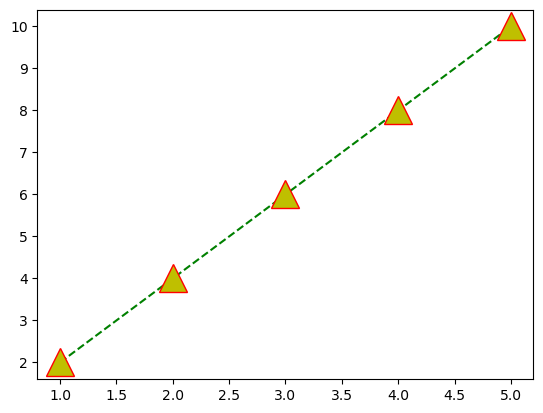

In [21]:
import matplotlib.pyplot as plt
import numpy as np

x = np.array([1, 2, 3, 4, 5])
y = np.array([2, 4, 6, 8, 10])

# Customize the plot
#plt.plot(x, y, color='red', linestyle='--', marker='o')
plt.plot(x,y,'g^--',mfc='y',mec='r',markersize=20)
plt.show()

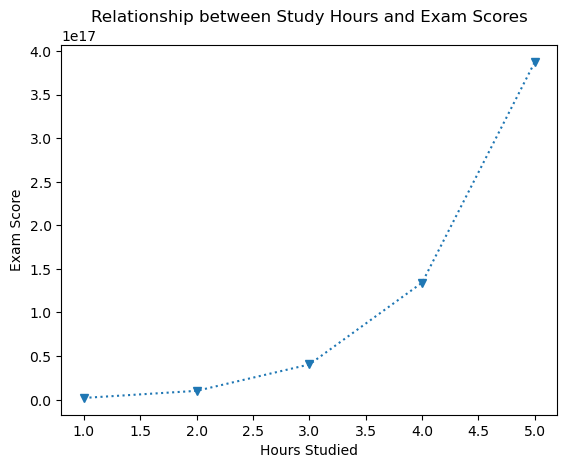

In [40]:
import matplotlib.pyplot as plt
import numpy as np

hours_studied = np.array([1, 2, 3, 4, 5])
exam_scores = np.array([50, 60, 70, 80, 90])

plt.plot(hours_studied, exam_scores**9,'v:')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Relationship between Study Hours and Exam Scores')

plt.show()